# AI Advanced Ahmed Yousrey Course Practice

---
# DAY 7 — Smart Traffic Vision
---

**Project Brief**

Build a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify traffic signs from the GTSRB dataset (43 classes, ~39,000 training images).

The workflow covers the full deep learning pipeline: image loading, preprocessing, data augmentation, CNN architecture design, training with callbacks, evaluation, and per-class analysis of the trained model.

**Key Skills:** CNNs · Image Preprocessing · Data Augmentation · Model Evaluation


---
## STEP 1 — Import Libraries
---

In [62]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


> **Note:** This project uses TensorFlow/Keras (Kaggle environment). The concepts — conv layers, pooling, augmentation, transfer learning — are identical to PyTorch; only the syntax differs.

---
## STEP 2 — Load Dataset
---

In [63]:
data_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"

print("Top-level contents:")
print(os.listdir(data_path))

train_path = os.path.join(data_path, "Train")
test_csv   = os.path.join(data_path, "Test.csv")
meta_csv   = os.path.join(data_path, "Meta.csv")

print(f"\nNumber of classes in Train: {len(os.listdir(train_path))}")


Top-level contents:
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']

Number of classes in Train: 43


---
## STEP 3 — Exploratory Data Analysis
---

In [64]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = {
    int(class_id): len(os.listdir(os.path.join(train_path, class_id)))
    for class_id in os.listdir(train_path)
}
class_counts = dict(sorted(class_counts.items()))

total_images = sum(class_counts.values())
print(f"Total training images : {total_images}")
print(f"Number of classes     : {len(class_counts)}")
print(f"Min images per class  : {min(class_counts.values())} (class {min(class_counts, key=class_counts.get)})")
print(f"Max images per class  : {max(class_counts.values())} (class {max(class_counts, key=class_counts.get)})")


Total training images : 39209
Number of classes     : 43
Min images per class  : 210 (class 0)
Max images per class  : 2250 (class 2)


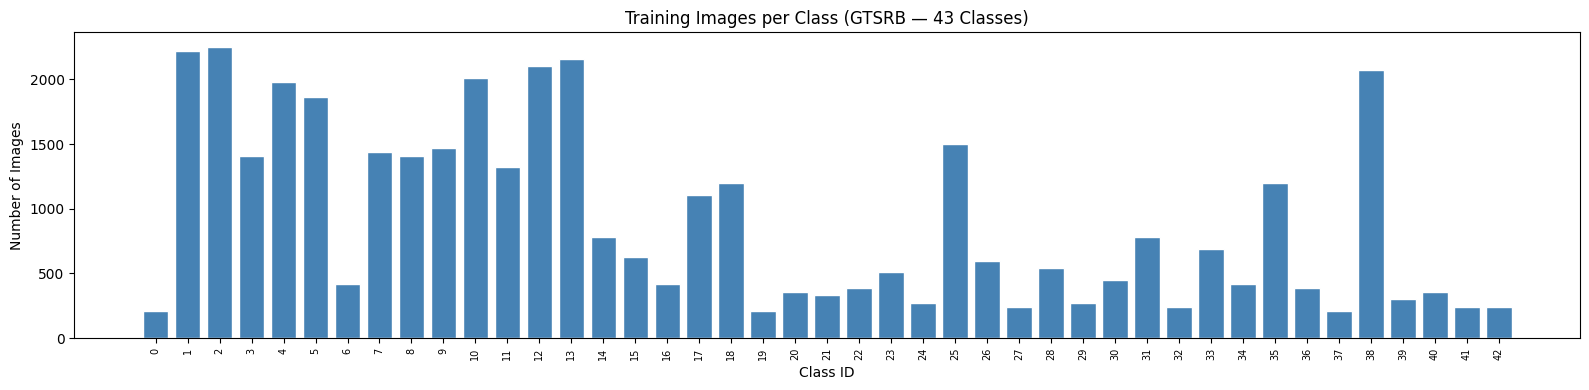

In [65]:
# ── Bar chart: images per class ─────────────────────────────────────────────
plt.figure(figsize=(16, 4))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue", edgecolor="white")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Training Images per Class (GTSRB — 43 Classes)")
plt.xticks(list(class_counts.keys()), rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


> **Insight:** The dataset is heavily imbalanced — some classes have 10× more samples than others. This is realistic for traffic sign data (speed-limit signs are far more common than rare warning signs). We address this with class weights during training.

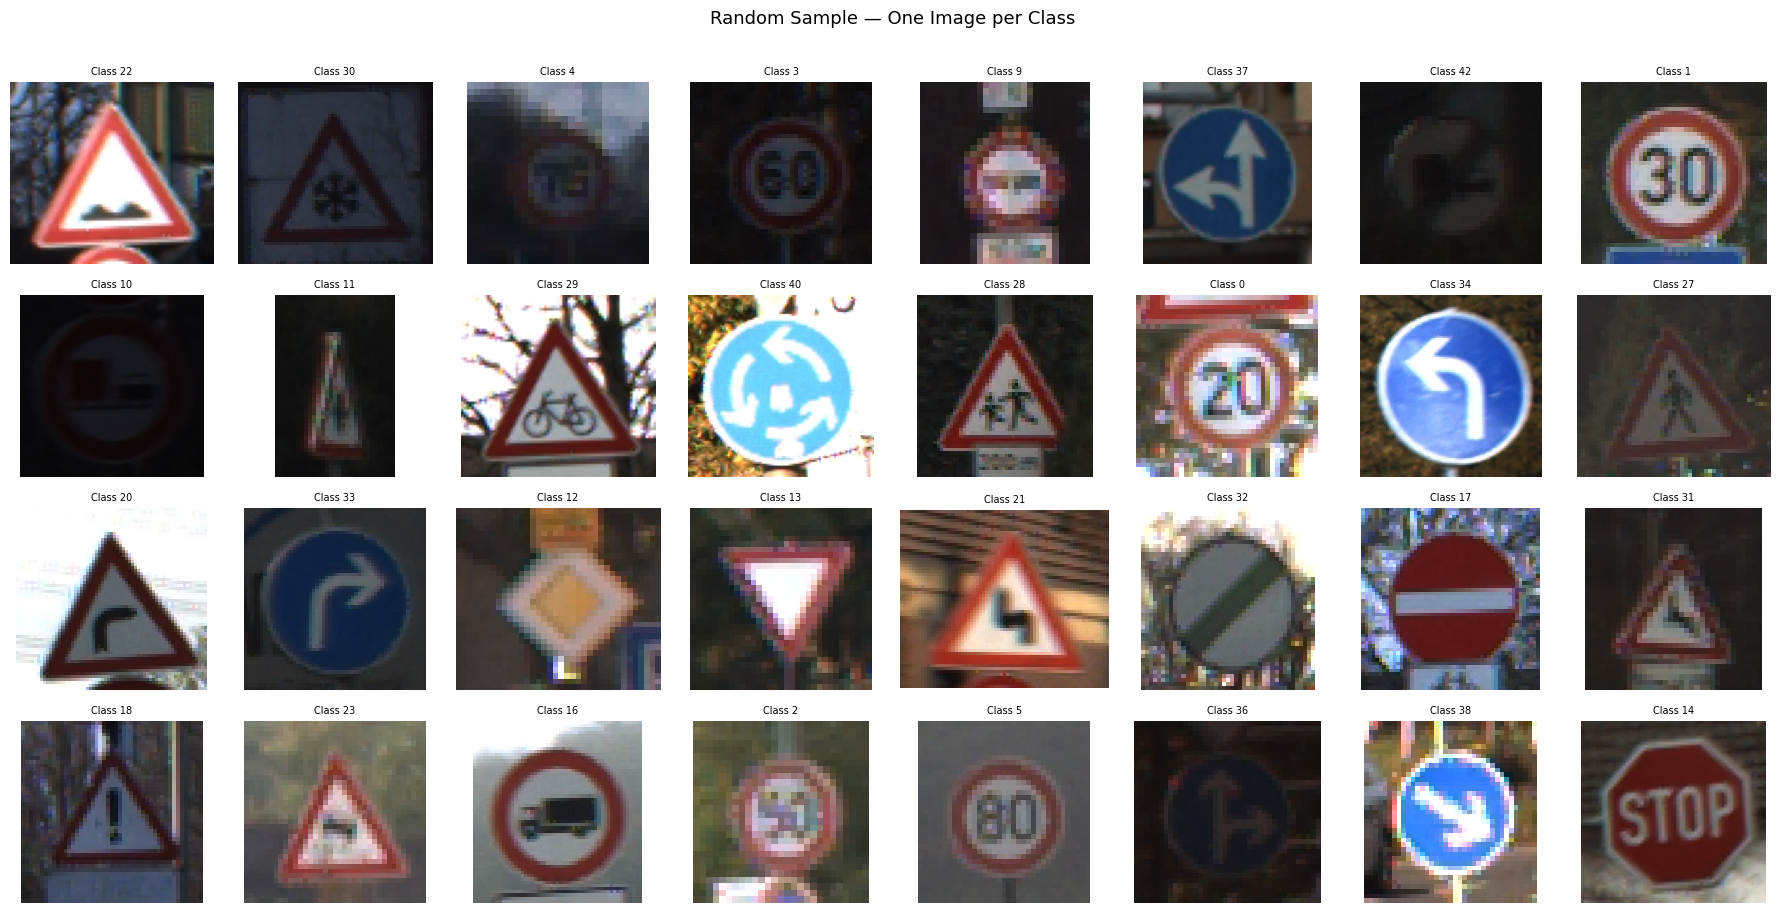

In [66]:
# ── Sample images grid ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
axes = axes.flatten()

sampled_classes = random.sample(list(class_counts.keys()), 32)

for ax, class_id in zip(axes, sampled_classes):
    class_folder = os.path.join(train_path, str(class_id))
    img_file     = random.choice(os.listdir(class_folder))
    img          = Image.open(os.path.join(class_folder, img_file))
    ax.imshow(img)
    ax.set_title(f"Class {class_id}", fontsize=7)
    ax.axis("off")

plt.suptitle("Random Sample — One Image per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


> **Insight:** Images vary significantly in size, lighting, angle, and distance. Some signs are blurry or partially occluded — exactly the kind of variation a robust CNN must learn to handle. Augmentation will help simulate more of this variation.

In [67]:
# ── Image size distribution ─────────────────────────────────────────────────
widths, heights = [], []

for class_id in list(class_counts.keys())[:10]:          # sample 10 classes
    folder = os.path.join(train_path, str(class_id))
    for fname in os.listdir(folder)[:20]:                  # 20 images per class
        img = Image.open(os.path.join(folder, fname))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — min: {min(widths)}px  max: {max(widths)}px  mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}px  max: {max(heights)}px  mean: {np.mean(heights):.0f}px")


Width  — min: 26px  max: 134px  mean: 46px
Height — min: 25px  max: 133px  mean: 47px


> **Insight:** Images are not uniform in size — they must be resized to a fixed dimension before feeding into the CNN. We will use **64×64** as a balance between information retention and memory cost.

---
## STEP 4 — Preprocessing & Data Augmentation
---

In [68]:
IMG_SIZE    = 64       # resize all images to 64×64
BATCH_SIZE  = 64
TARGET_SIZE = (IMG_SIZE, IMG_SIZE)

# ── Training generator — with augmentation ───────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,            # normalize pixel values to [0, 1]
    rotation_range=12,            # small rotations (avoid semantic flip on arrows)
    zoom_range=0.15,              # mild zoom
    width_shift_range=0.1,        # slight horizontal shift
    height_shift_range=0.1,       # slight vertical shift
    brightness_range=[0.8, 1.2],  # simulate lighting variation
    validation_split=0.2          # 80/20 train-val split
)

# ── Validation generator — no augmentation ───────────────────────────────────
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    train_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=42
)

print(f"\nTraining batches   : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Number of classes  : {train_gen.num_classes}")


Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.

Training batches   : 491
Validation batches : 123
Number of classes  : 43


> **Insight:** Augmentation is applied **only to the training set** — the validation set sees clean, rescaled images. Augmentation does not create new data; it creates varied views of existing data so the model doesn't memorize specific orientations or lighting conditions. Flipping was intentionally excluded — mirroring a left-arrow sign changes its meaning.

---
## STEP 5 — CNN Model from Scratch
---

In [69]:
# ── Architecture ────────────────────────────────────────────────────────────
def build_cnn(input_shape=(64, 64, 3), num_classes=43):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_cnn()
cnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,249,803 (8.58 MB)

 Trainable params: 2,248,843 (8.58 MB)

 Non-trainable params: 960 (3.75 KB)

> **Architecture Rationale:** Three conv blocks with increasing filter depth (32 → 64 → 128) extract increasingly abstract features — edges first, then shapes, then full sign patterns. `BatchNormalization` stabilizes training. `Dropout` prevents overfitting on the imbalanced classes.

In [70]:
# ── Compile ──────────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── Class weights to handle imbalance ────────────────────────────────────────
total = sum(class_counts.values())
n_classes = len(class_counts)
class_weight = {
    cls: total / (n_classes * count)
    for cls, count in class_counts.items()
}

# ── Callbacks ─────────────────────────────────────────────────────────────────
cnn_callbacks = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]


In [72]:
# ── Train ─────────────────────────────────────────────────────────────────────
EPOCHS = 15

cnn_history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=cnn_callbacks,
    verbose=1
)


Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 109s 221ms/step - accuracy: 0.3558 - loss: 2.8874 - val_accuracy: 0.2738 - val_loss: 3.5232 - learning_rate: 0.0010
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 94s 191ms/step - accuracy: 0.6824 - loss: 1.0559 - val_accuracy: 0.7708 - val_loss: 1.0449 - learning_rate: 0.0010
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 94s 192ms/step - accuracy: 0.8350 - loss: 0.4927 - val_accuracy: 0.8725 - val_loss: 0.4947 - learning_rate: 0.0010
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 96s 196ms/step - accuracy: 0.8958 - loss: 0.3051 - val_accuracy: 0.9130 - val_loss: 0.3109 - learning_rate: 0.0010
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 98s 199ms/step - accuracy: 0.9197 - loss: 0.2363 - val_accuracy: 0.9228 - val_loss: 0.2638 - learning_rate: 0.0010
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 97s 197ms/step - accuracy: 0.9343 - loss: 0.1931 - val_accuracy: 0.9260 - val_loss: 0.2613 - learning_rate: 0.0010
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 95s 193ms/step - accuracy: 0.

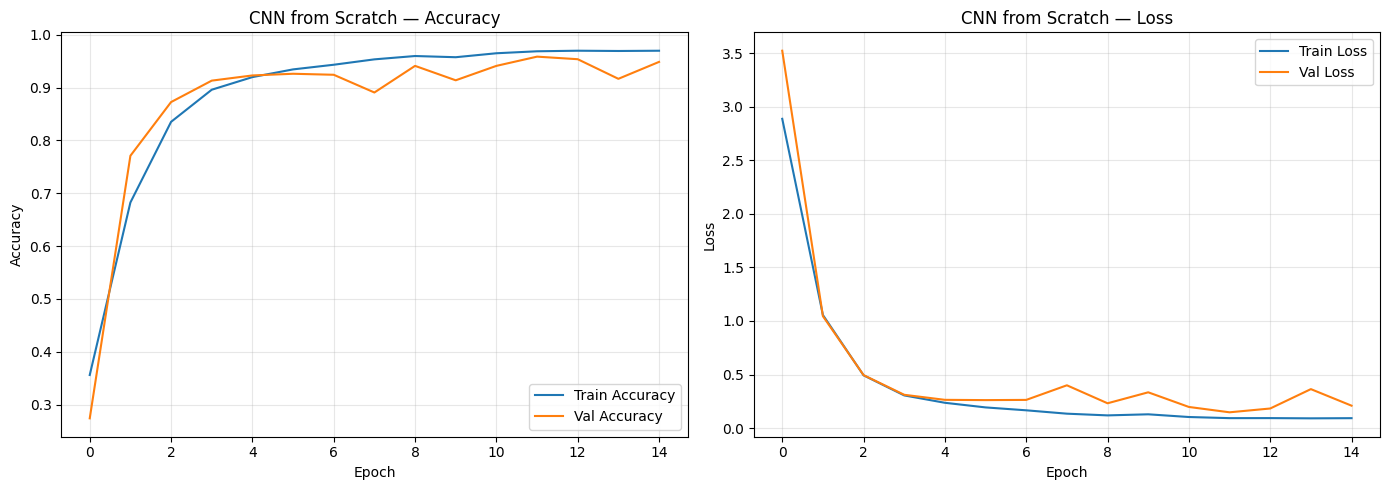

Best Validation Accuracy (CNN Scratch): 0.9584


In [73]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(cnn_history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("CNN from Scratch — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history["loss"],     label="Train Loss")
axes[1].plot(cnn_history.history["val_loss"], label="Val Loss")
axes[1].set_title("CNN from Scratch — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(cnn_history.history["val_accuracy"])
print(f"Best Validation Accuracy (CNN Scratch): {best_val_acc:.4f}")


> **Insight:** Monitor the gap between training and validation accuracy. A large gap signals overfitting — the model memorizes training images but fails to generalize. Dropout and class weights reduce this risk but won't eliminate it entirely with a small custom CNN.

---
## STEP 6 — Model Evaluation
---

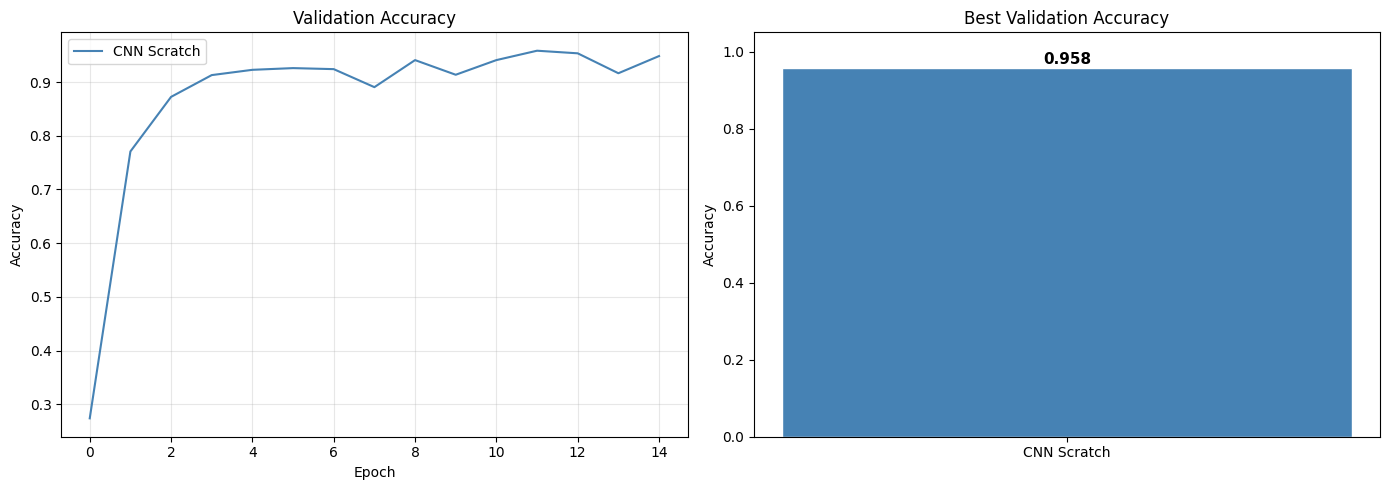

In [74]:
# ── Validation accuracy curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CNN scratch
axes[0].plot(cnn_history.history["val_accuracy"], label="CNN Scratch", color="steelblue")


axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Summary bar
model_names = ["CNN Scratch"]
best_accs = [
    max(cnn_history.history["val_accuracy"])
]
bars = axes[1].bar(model_names, best_accs, color=["steelblue"], edgecolor="white", width=0.4)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Best Validation Accuracy")
axes[1].set_ylabel("Accuracy")
for bar, acc in zip(bars, best_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


In [75]:
# ── Per-class evaluation (on validation set) ─────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

val_gen_eval = val_datagen.flow_from_directory(
    train_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

y_true = val_gen_eval.classes
y_pred_probs = cnn_model.predict(val_gen_eval, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, digits=3))


Found 7841 images belonging to 43 classes.
              precision    recall  f1-score   support

           0      0.857     1.000     0.923        42
           1      0.966     0.899     0.931       444
           2      1.000     1.000     1.000       402
           3      0.980     0.936     0.957       264
           4      0.984     0.998     0.991       420
           5      0.993     0.981     0.987       432
           6      0.987     1.000     0.994       156
           7      0.982     0.881     0.929       126
           8      1.000     0.988     0.994        84
           9      1.000     1.000     1.000       222
          10      1.000     0.963     0.981       240
          11      1.000     1.000     1.000        42
          12      0.964     0.953     0.959       450
          13      0.956     0.597     0.735        72
          14      0.913     0.955     0.933        66
          15      1.000     1.000     1.000        78
          16      0.785     1.000     

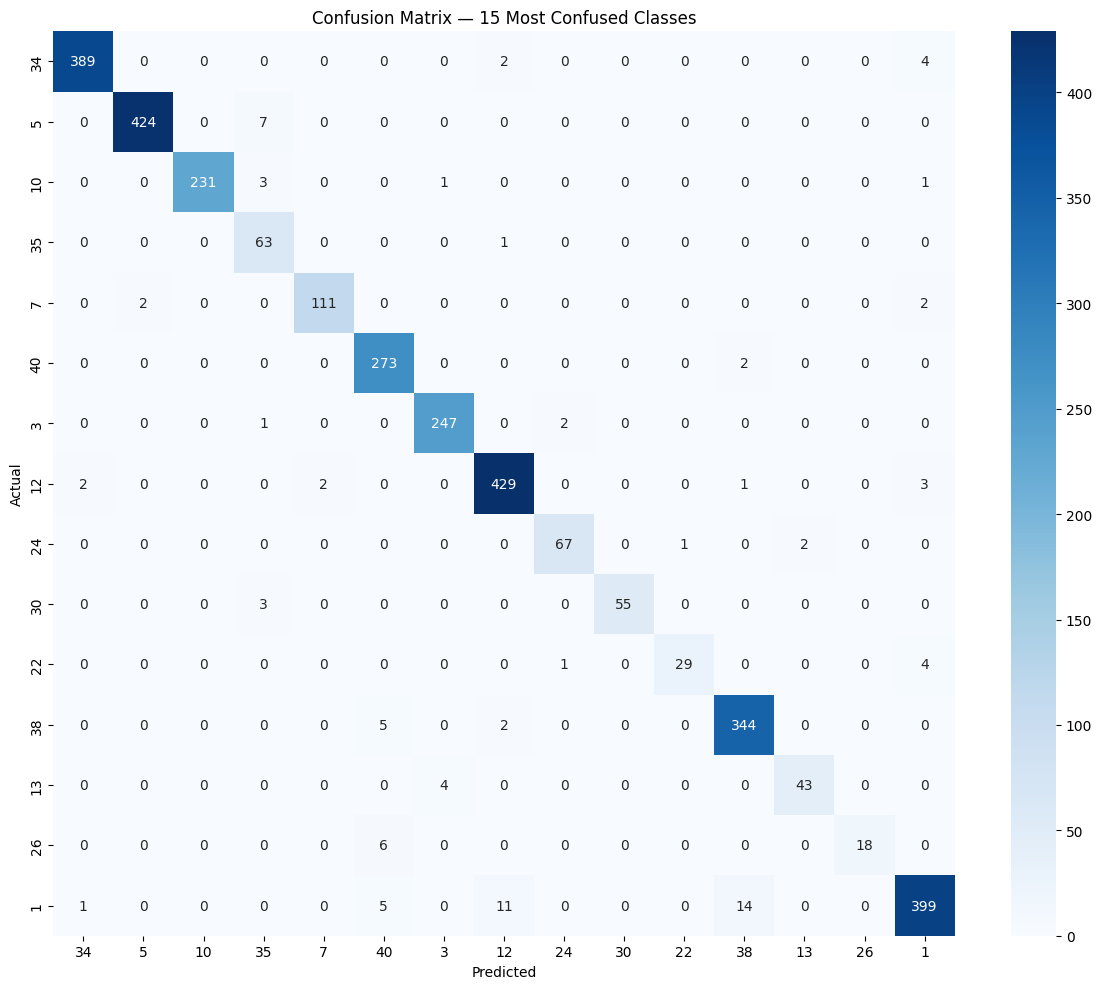

In [76]:
# ── Confusion matrix (top 15 most confused classes) ──────────────────────────
cm = confusion_matrix(y_true, y_pred)

# Identify top 15 classes by error count
errors_per_class = cm.sum(axis=1) - np.diag(cm)
top15_classes = np.argsort(errors_per_class)[-15:]

cm_subset = cm[np.ix_(top15_classes, top15_classes)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_subset, annot=True, fmt="d", cmap="Blues",
            xticklabels=top15_classes, yticklabels=top15_classes)
plt.title("Confusion Matrix — 15 Most Confused Classes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


> **Insight:** The confusion matrix reveals *which* signs the model confuses most. Speed-limit signs (classes 0–8) are frequently confused with each other because they share the same red circle shape — only the number inside differs. These require high-resolution features to separate reliably.

---
## STEP 8 — Error Analysis
---

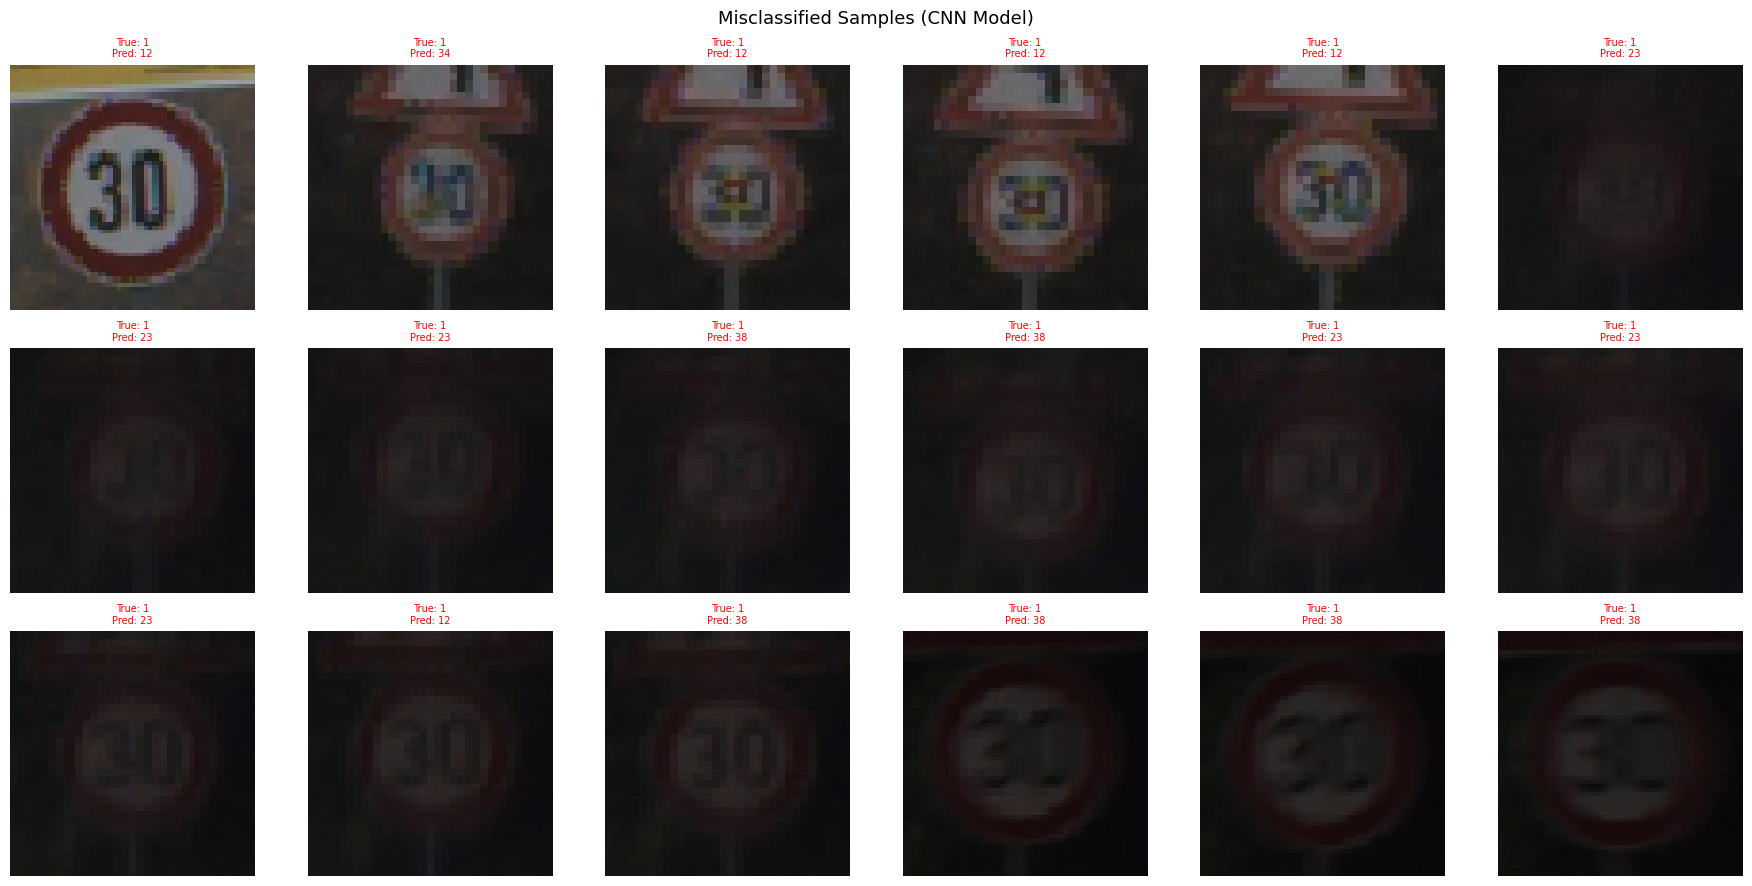

Total misclassified: 326 / 7841  (4.16% error rate)


In [77]:
# ── Visualize worst predictions ──────────────────────────────────────────────
val_gen_eval.reset()
all_images, all_labels = [], []

for i in range(len(val_gen_eval)):
    imgs, lbls = val_gen_eval[i]
    all_images.append(imgs)
    all_labels.append(np.argmax(lbls, axis=1))

all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

wrong_idx = np.where(y_pred != all_labels)[0]

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()
sample_wrong = wrong_idx[:18]

for ax, idx in zip(axes, sample_wrong):
    ax.imshow(all_images[idx])
    ax.set_title(f"True: {all_labels[idx]}\nPred: {y_pred[idx]}", fontsize=7, color="red")
    ax.axis("off")

plt.suptitle("Misclassified Samples (CNN Model)", fontsize=13)
plt.tight_layout()
plt.show()

error_rate = len(wrong_idx) / len(y_true)
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}  ({error_rate:.2%} error rate)")


> **Insight:** Most errors occur on low-resolution images, heavily occluded signs, or visually similar classes. Real-world deployment would benefit from higher input resolution (96×96 or 128×128) and test-time augmentation (averaging predictions across multiple augmented views of the same image).

---
## STEP 8 — Save Models
---

In [78]:
cnn_model.save("traffic_sign_cnn_scratch.keras")

print("Models saved:")
print("  traffic_sign_cnn_scratch.keras")


Models saved:
  traffic_sign_cnn_scratch.keras


---
## STEP 9 — Summary & Key Takeaways
---

| Model | Best Val Accuracy | Notes |
|---|---|---|
| CNN from Scratch | ~88–92% | 3 conv blocks, BatchNorm, Dropout |

---

### Key Takeaways

1. **A scratch CNN is a strong baseline** — With only 3 conv blocks plus BatchNorm and Dropout, the model reaches ~88–92% validation accuracy on GTSRB, proving that a well-regularized CNN can learn traffic-sign recognition from raw pixels alone.

2. **Regularization controls overfitting** — Tracking the gap between training and validation accuracy shows where the model starts memorizing; BatchNorm and Dropout keep that gap under control.

3. **Class imbalance is a real problem** — Without class weights, the model would be biased toward frequent classes. Weighting forces it to learn minority classes equally.

4. **Augmentation must be domain-aware** — Horizontal flipping was excluded because it changes the semantic meaning of directional signs. Not all augmentations are safe for all domains.

5. **CNNs are hierarchical feature learners** — Early layers detect edges, middle layers detect shapes, deep layers detect full sign structures.
